#**Using Naive Bayes Method**

In [33]:
#Required Libraries
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
#Downloading the necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [35]:
#Defining the Function to load data
def load_data(filepath):
    df = pd.read_csv(filepath, encoding='latin-1', usecols=[0, 1], names=['Label', 'Message'], header=0)
    return df

#Defining the Function to preprocess text
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    table = str.maketrans('', '', string.punctuation)
    stripped = [w.translate(table) for w in tokens]
    words = [word for word in stripped if word.isalpha()]
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if not w in stop_words]
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)

In [36]:
#Load and preprocess data
df = load_data('spam.csv')
df['Message'] = df['Message'].apply(preprocess_text)

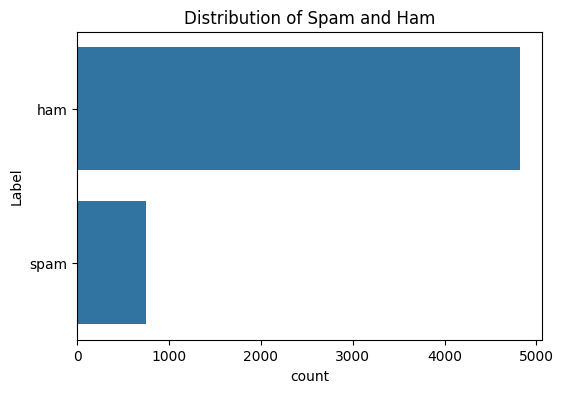

In [37]:
#Visualize the distribution of classes
plt.figure(figsize=(6,4))
sns.countplot(df['Label'])
plt.title('Distribution of Spam and Ham')
plt.show()

In [38]:
#Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df['Message'], df['Label'], test_size=0.2, random_state=42)

#Create a pipeline for vectorization and Naive Bayes classification
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', MultinomialNB()),
])

#Train the model
pipeline.fit(X_train, y_train)

#Predict on the test data
y_pred = pipeline.predict(X_test)

In [39]:
#Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9659192825112107
Confusion Matrix:
 [[965   0]
 [ 38 112]]
Classification Report:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



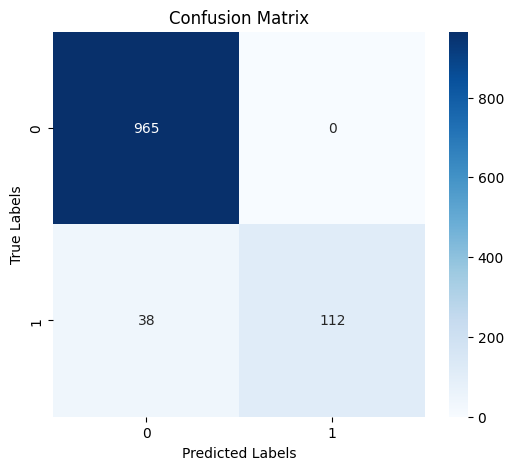

In [40]:
#Plotting the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#**Using SVM Method**

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Creating a Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm_classifier', SVC(kernel='linear'))
])

#Train the pipeline on the training data
pipeline.fit(X_train, y_train)

#Predict on the test data using the same pipeline
y_pred = pipeline.predict(X_test)

#Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
class_names = ['Ham', 'Spam']

#Print the results
print("Accuracy of SVM Classifier:", accuracy)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)


Accuracy of SVM Classifier: 0.9766816143497757
Confusion Matrix:
 [[961   4]
 [ 22 128]]
Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.97      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.97      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



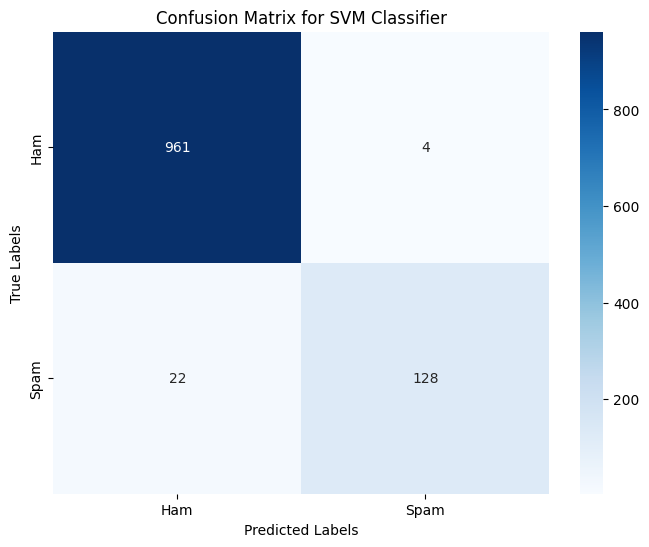

In [42]:
#Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()